In [1]:
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Notebook last run (end-to-end): 2026-08-29 21:58:58.371045


In [2]:
import tensorflow as tf
import os

In [3]:
for dirpath,dirnames,filenames in os.walk(r'D:\tensorflow\101_food_classes_10_percent'):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

There are 2 directories and 0 images in D:\tensorflow\101_food_classes_10_percent
There are 101 directories and 0 images in D:\tensorflow\101_food_classes_10_percent\test
There are 0 directories and 250 images in D:\tensorflow\101_food_classes_10_percent\test\apple_pie
There are 0 directories and 250 images in D:\tensorflow\101_food_classes_10_percent\test\baby_back_ribs
There are 0 directories and 250 images in D:\tensorflow\101_food_classes_10_percent\test\baklava
There are 0 directories and 250 images in D:\tensorflow\101_food_classes_10_percent\test\beef_carpaccio
There are 0 directories and 250 images in D:\tensorflow\101_food_classes_10_percent\test\beef_tartare
There are 0 directories and 250 images in D:\tensorflow\101_food_classes_10_percent\test\beet_salad
There are 0 directories and 250 images in D:\tensorflow\101_food_classes_10_percent\test\beignets
There are 0 directories and 250 images in D:\tensorflow\101_food_classes_10_percent\test\bibimbap
There are 0 directories and

In [4]:
# Create tensorboard callback (functionized because need to create a new one for each model)
import datetime
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

In [5]:
train_dir = r"D:\tensorflow\101_food_classes_10_percent\train"
test_dir = r"D:\tensorflow\101_food_classes_10_percent\test/"

In [6]:
import tensorflow as tf
IMG_SIZE = (224, 224)
train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE)
                                                                                
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                shuffle=False) # don't shuffle test data for prediction analysis

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [7]:
# Create checkpoint callback to save model for later use
checkpoint_path = "101_classes_10_percent_data_model_checkpoint"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True, # save only the model weights
                                                         monitor="val_accuracy", # save the model weights which score the best validation accuracy
                                                         save_best_only=True) # only keep the best model weights on file (delete the rest)

In [8]:
# Import the required modules for model creation
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

## NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomHeight(0.2),
  layers.RandomWidth(0.2),
], name ="data_augmentation")

In [9]:
base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3), name="input_layer") # shape of input image
x = data_augmentation(inputs) 
x = base_model(x, training=False) 
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x) 
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation="softmax", name="output_layer")(x) 
model = tf.keras.Model(inputs, outputs)

In [10]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 efficientnetb0 (Functional)  (None, None, None, 1280)  4049571  
                                                                 
 global_average_pooling (Glo  (None, 1280)             0         
 balAveragePooling2D)                                            
                                                                 
 output_layer (Dense)        (None, 101)               129381    
                                                                 
Total params: 4,178,952
Trainable params: 129,381
Non-trainab

In [11]:
# Compile
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(), 
              metrics=["accuracy"])

# Fit
history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                           epochs=5, 
                                           validation_data=test_data,
                                           validation_steps=int(0.15 * len(test_data)), 
                                           callbacks=[checkpoint_callback])

Epoch 1/5
237/237 [==============================] - 92s 345ms/step - loss: 3.3815 - accuracy: 0.2690 - val_loss: 2.5340 - val_accuracy: 0.4298
Epoch 2/5
237/237 [==============================] - 93s 391ms/step - loss: 2.1883 - accuracy: 0.4961 - val_loss: 2.0346 - val_accuracy: 0.5103
Epoch 3/5
237/237 [==============================] - 85s 357ms/step - loss: 1.8223 - accuracy: 0.5657 - val_loss: 1.8814 - val_accuracy: 0.5267
Epoch 4/5
237/237 [==============================] - 74s 312ms/step - loss: 1.6017 - accuracy: 0.6077 - val_loss: 1.8529 - val_accuracy: 0.5201
Epoch 5/5
237/237 [==============================] - 73s 308ms/step - loss: 1.4604 - accuracy: 0.6397 - val_loss: 1.7699 - val_accuracy: 0.5352


In [12]:
results_feature_extraction_model = model.evaluate(test_data)
results_feature_extraction_model

790/790 [==============================] - 99s 125ms/step - loss: 1.5916 - accuracy: 0.5787


[1.5916374921798706, 0.5786930918693542]

In [13]:
# If you wanted to, you could really turn this into a helper function to load in with a helper.py script...
import matplotlib.pyplot as plt

# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

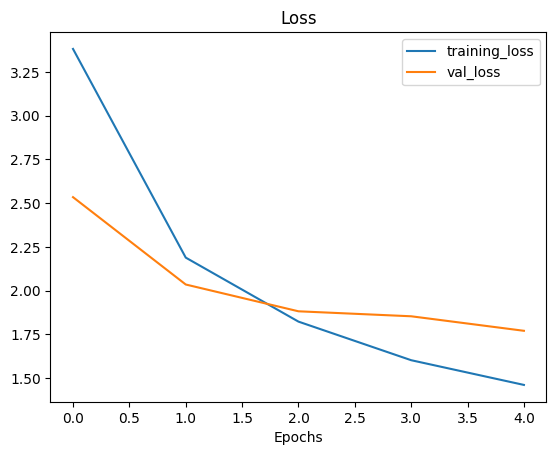

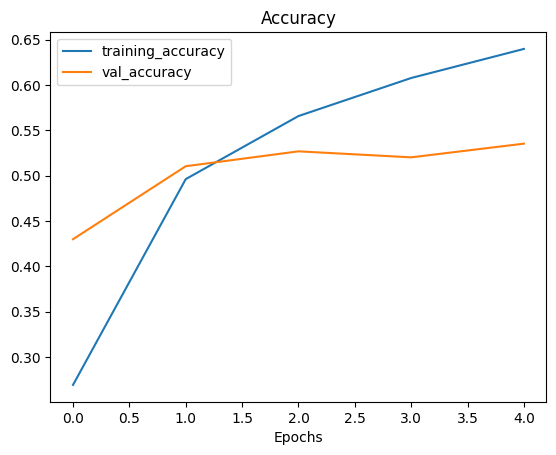

In [14]:
plot_loss_curves(history_all_classes_10_percent)

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-5]:
  layer.trainable = False

In [16]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-4), # 10x lower learning rate than default
              metrics=['accuracy'])

In [17]:
for layer in model.layers:
  print(layer.name, layer.trainable)

input_layer True
data_augmentation True
efficientnetb0 True
global_average_pooling True
output_layer True


In [18]:
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_1 False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze False
39

In [19]:
fine_tune_epochs = 10 

history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)), 
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1]) 

Epoch 5/10
237/237 [==============================] - 85s 327ms/step - loss: 1.2097 - accuracy: 0.6820 - val_loss: 1.7079 - val_accuracy: 0.5466
Epoch 6/10
237/237 [==============================] - 87s 366ms/step - loss: 1.0867 - accuracy: 0.7067 - val_loss: 1.7459 - val_accuracy: 0.5437
Epoch 7/10
237/237 [==============================] - 84s 352ms/step - loss: 1.0008 - accuracy: 0.7304 - val_loss: 1.7394 - val_accuracy: 0.5474
Epoch 8/10
237/237 [==============================] - 76s 321ms/step - loss: 0.9449 - accuracy: 0.7484 - val_loss: 1.7624 - val_accuracy: 0.5421
Epoch 9/10
237/237 [==============================] - 77s 323ms/step - loss: 0.8746 - accuracy: 0.7646 - val_loss: 1.7558 - val_accuracy: 0.5405
Epoch 10/10
237/237 [==============================] - 75s 314ms/step - loss: 0.8350 - accuracy: 0.7795 - val_loss: 1.7400 - val_accuracy: 0.5456


In [20]:
results_all_classes_10_percent_fine_tune = model.evaluate(test_data)
results_all_classes_10_percent_fine_tune

790/790 [==============================] - 90s 114ms/step - loss: 1.4998 - accuracy: 0.6019


[1.4998047351837158, 0.6019009947776794]

In [21]:
def compare_historys(original_history, new_history, initial_epochs=5):
    """
    Compares two model history objects.
    """
    acc = original_history.history["accuracy"]
    loss = original_history.history["loss"]

    print(len(acc))

    val_acc = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    total_acc = acc + new_history.history["accuracy"]
    total_loss = loss + new_history.history["loss"]

    total_val_acc = val_acc + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    print(len(total_acc))
    print(total_acc)

    # Make plots
    plt.figure(figsize=(8, 8))
    plt.subplot(2, 1, 1)
    plt.plot(total_acc, label='Training Accuracy')
    plt.plot(total_val_acc, label='Validation Accuracy')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 1, 2)
    plt.plot(total_loss, label='Training Loss')
    plt.plot(total_val_loss, label='Validation Loss')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('epoch')
    plt.show()

5
11
[0.2690429091453552, 0.4961056113243103, 0.5656765699386597, 0.6076567769050598, 0.639735996723175, 0.6819801926612854, 0.7066666483879089, 0.7304290533065796, 0.7483828663825989, 0.7646204829216003, 0.7795379757881165]


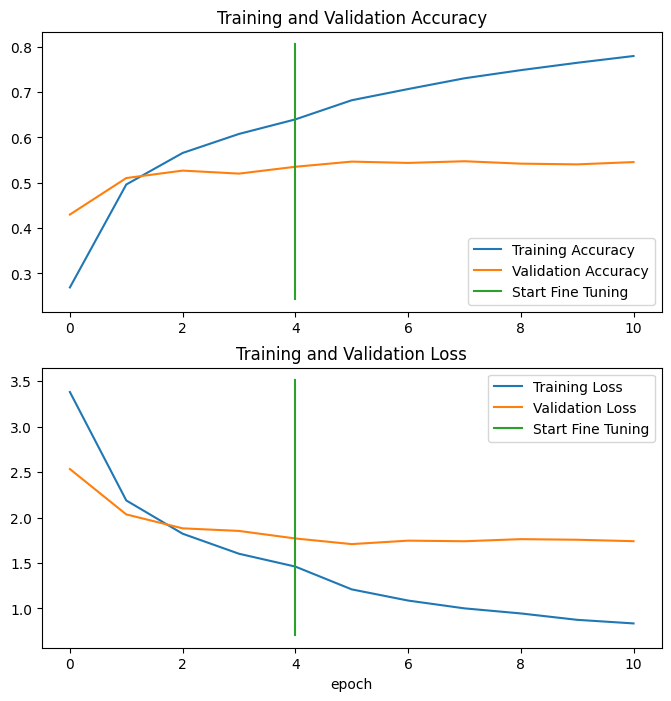

In [22]:
compare_historys(original_history=history_all_classes_10_percent,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

In [23]:
saved_model_path = r"D:\tensorflow\06_101_food_class_10_percent_saved_big_dog_model"
model = tf.keras.models.load_model(saved_model_path.split(".")[0])

In [24]:
loaded_loss , loaded_accuracy = model.evaluate(test_data)
loaded_loss, loaded_accuracy 

790/790 [==============================] - 75s 93ms/step - loss: 1.8019 - accuracy: 0.6077


(1.8019390106201172, 0.6077227592468262)

In [25]:
pred_probs = model.predict(test_data, verbose=1)

790/790 [==============================] - 73s 91ms/step


In [26]:
len(pred_probs)

25250

In [27]:
pred_probs.shape

(25250, 101)

In [28]:
pred_probs[:10]

array([[5.95736541e-02, 3.60441186e-06, 4.14392613e-02, ...,
        1.41838785e-09, 8.53106540e-05, 3.08756018e-03],
       [9.63171601e-01, 1.38688383e-09, 8.55273509e-04, ...,
        5.40431429e-05, 7.78548059e-12, 9.86026816e-10],
       [9.59344625e-01, 3.22777887e-05, 1.49324082e-03, ...,
        7.10734241e-07, 5.49974970e-07, 3.99208948e-05],
       ...,
       [4.74982888e-01, 1.29669672e-07, 1.46825751e-03, ...,
        5.84984547e-04, 6.72626629e-05, 2.34009203e-05],
       [4.49851230e-02, 4.72171166e-07, 1.23602435e-01, ...,
        6.24433505e-06, 7.54086022e-06, 3.66840931e-03],
       [7.25333393e-01, 1.92720573e-09, 5.24190691e-05, ...,
        1.21750019e-03, 1.57230051e-09, 9.61082769e-05]], dtype=float32)

In [29]:
print(f"Number of prediction probabilities for sample 0: {len(pred_probs[0])}")
print(f"What prediction probability sample 0 looks like:\n {pred_probs[0]}")
print(f"The class with the highest predicted probability by the model for sample 0: {pred_probs[0].argmax()}")

Number of prediction probabilities for sample 0: 101
What prediction probability sample 0 looks like:
 [5.95736541e-02 3.60441186e-06 4.14392613e-02 1.07950338e-09
 8.41602432e-09 8.71430395e-09 8.01640340e-07 8.52923392e-07
 1.99753686e-05 8.05688614e-07 3.17991922e-09 9.88738748e-07
 2.82316061e-04 7.80763454e-10 7.45836238e-04 3.92836955e-05
 6.53069492e-06 2.51601659e-06 3.77399410e-05 2.04158070e-07
 1.57210998e-05 8.05134107e-07 2.60489560e-06 2.01965932e-07
 8.30893043e-07 5.49847300e-06 3.80234451e-06 1.32772895e-08
 2.74651009e-03 2.80413988e-05 6.98016145e-10 2.52657355e-05
 1.67082748e-04 7.71212538e-10 4.08256048e-04 1.31679609e-08
 1.80135623e-06 1.45871604e-06 2.33000498e-02 8.31276566e-07
 8.66269090e-07 1.68605436e-06 7.04090826e-06 1.87270874e-08
 2.90242980e-07 8.01802889e-06 2.10209828e-06 1.87553695e-07
 3.38154287e-08 3.17653699e-04 1.05544250e-05 8.71800353e-07
 8.46994221e-01 1.05987265e-05 4.33128548e-07 3.75615637e-05
 3.54158183e-05 3.30281109e-05 6.70573427e-